In [147]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pymc as pm
import pymc_extras as pmx
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import matplotlib.cm as cm
import arviz as az
from sklearn.preprocessing import StandardScaler
import pytensor.tensor as pt
import matplotlib.cm as cm
#import regionmask
#import cartopy.crs as ccrs
from geopy.geocoders import Nominatim
import cartopy.crs as ccrs

np.random.seed(666)

In [273]:
NA=xr.open_dataset("/DATA/IMERG/prec_indices_map_NA.nc")
list(NA)

['AnnualMean', 'RX1day', 'RX5day', 'R10', 'R20', 'R95p', 'R99p', 'PRCPTOT']

In [46]:
citylookup={}
citylookup["New York City"]=()
citylookup["Chicago"]=(41.88,-87.63)
citylookup["Ithaca"]= (42.4440, -76.5019)
citylookup["Reno"]= (39.53, -119.81)
    

I assume the following distributions:
* Normal: AnnualMean
* GEV: 'RX1day', 'RX5day' (these are block maxima)
* Poisson: 'R10', 'R20'

In [274]:
def get_lat_lon(city_name: str):
    if city_name in citylookup.keys():
        return citylookup[city_name]
    else:
        geolocator = Nominatim(user_agent="city_lookup_script")
        location = geolocator.geocode(city_name)
    
        if location:
            citylookup[city_name]=( location.latitude, location.longitude)
            return location.latitude, location.longitude
        else:
            return None, None
def get_data(city_name):
    lat,lon=get_lat_lon(city_name)
    return NA.sel(lat=lat,lon=lon,method="nearest")


In [288]:
def build_poisson_model(model,data):
    y=data.values
    years = np.arange(0, len(y))
    coords={"time":data.time.values}
    with model:
        for k,v in coords.items():
            model.add_coord(k,v)
        #observations=pm.Data("observations",y)
        # Priors for log-linear Poisson regression
        alpha = pm.Normal("alpha", mu=np.log(y.mean()), sigma=2)
        beta = pm.Normal("beta", mu=0, sigma=1)  
        
        # Log-linear model
        mu = alpha + beta * years
        lam = pm.math.exp(mu)
        #Interpretation of beta: percent change per year
        trend=pm.Deterministic("trend",(pm.math.exp(beta)-1)*100)
        
        # Poisson likelihood
        observed = pm.Poisson("observed", mu=lam, observed=y,dims=("time"))
    
        
        return {"alpha":alpha,
                "beta":beta,
                "trend":trend
                }
    




In [304]:
def build_GEV_model(model,data):
    ps = [1/10,1/25,1/100]
    y=data.values
    years = np.arange(0, len(y))
    coords={"time":data.time.values}
    with model:
        for k,v in coords.items():
            model.add_coord(k,v)
    
        # Priors
        trend = pm.Normal("trend",0,1)
        intercept=pm.Normal("intercept",0,1)
        #μ = pm.Normal("μ", mu=50, sigma=1)
        μ=trend*t+intercept
        σ = pm.HalfNormal("σ", sigma=1)
        ξ = pm.TruncatedNormal("ξ", mu=0, sigma=0.2, lower=-0.5, upper=0.5)
        
    
        # Estimation
        observed = pmx.GenExtreme("observed", mu=μ, sigma=σ, xi=ξ, observed=modeldata)
        # Return levels
        zp={}
        for p in ps:
            zp[str(int(1/p))] = pm.Deterministic("z_"+str(int(1/p)), μ - σ / ξ * (1 - (-np.log(1 - p)) ** (-ξ)),dims=("time"))
        return {"trend":trend,"intercept":intercept,"ξ":ξ,"σ":σ} | zp

In [300]:
def plot_poisson_trace(trace,var_name=""):
    # Get observed data from idata object
    data_plot= trace.observed_data.observed
    # Extract posterior samples
    alpha_samples = trace.posterior["alpha"].values.flatten()
    beta_samples = trace.posterior["beta"].values.flatten()
    
    # Number of posterior samples to plot for uncertainty
    n_samples = 100
    
    # Sample indices to plot
    idx = np.random.choice(len(alpha_samples), n_samples, replace=False)
    
    # Years for plotting
    years_plot = np.arange(1998, 1998 + len(data))
    
    # Plot observed counts
    plt.figure(figsize=(10,6))
    plt.scatter(years_plot, data_plot.values, color='black', label='Observed counts')
    
    # Plot posterior trend lines
    for i in idx:
        lam = np.exp(alpha_samples[i] + beta_samples[i] * np.arange(len(y)))
        plt.plot(years_plot, lam, color='orange', alpha=0.1)
    
    # Plot posterior mean trend
    lam_mean = np.exp(np.mean(alpha_samples) + np.mean(beta_samples) * np.arange(len(y)))
    plt.plot(years_plot, lam_mean, color='red', lw=2, label='Posterior mean trend')
    
    plt.xlabel('Year')
    plt.ylabel('Counts')
    plt.title(f'Observed {var_name} with posterior predictive trends')
    plt.legend()



In [306]:
def plot_GEV_trace(trace,var_name=""):
    data_plot= trace.observed_data.observed
    # Extract posterior samples
    intercept_samples = trace.posterior["intercept"].values.flatten()
    trend_samples = trace.posterior["trend"].values.flatten()
    
    # Number of posterior samples to plot for uncertainty
    n_samples = 100
    
    # Sample indices to plot
    idx = np.random.choice(len(intercept_samples), n_samples, replace=False)
    
    # Years for plotting
    years_plot = np.arange(1998, 1998 + len(y))
    
    # Plot observed counts
    plt.figure(figsize=(10,6))
    plt.scatter(years_plot, data_plot, color='black', label='Observed')
    
    # Plot posterior trend lines
    for i in idx:
        #lam = np.exp(alpha_samples[i] + beta_samples[i] * np.arange(len(y)))
        μ= trend_samples[i] * np.arange(len(y)) + intercept_samples[i]
        plt.plot(years_plot, μ, color='orange', alpha=0.1)
    
    # Plot posterior mean trend
    #lam_mean = np.exp(np.mean(alpha_samples) + np.mean(beta_samples) * np.arange(len(y)))
    mu_mean= np.mean(trend_samples) * np.arange(len(y)) + np.mean(intercept_samples)
    plt.plot(years_plot, mu_mean, color='red', lw=2, label='Posterior mean trend')
    
    plt.xlabel('Year')
    plt.ylabel('Rx1day')
    plt.title(f'Observed {var_name} with posterior predictive trends')
    plt.legend()
    t=np.arange(len(y))
    p=np.polyfit(t,modeldata,1)
    plt.plot(years_plot,np.polyval(p,t),label="OLS")
    plt.legend()
#plt.show()


In [332]:
class Data():
    def __init__(self,city_name):
        self.city_name=city_name
        self.data=get_data(city_name)
        self.models={}
        self.traces={}
    def center_data(self,index):
        D=getattr(self.data,index)
        return (D-D.mean(dim="time"))/D.std(dim="time")
    def prep_data(self,index):
        if index in ["R10","R20"]:
        #if D.values.dtype=='timedelta64[ns]':
            D=getattr(self.data,index)
            return D/np.timedelta64(1, 'D')
        else:
            return self.center_data(index)
    def uncenter_data(self,data,index):
        D=getattr(self.data,index)
        return D.std(dim="time")*data+D.mean(dim="time")
    def fit_model(self,index,force_recompile=False):
        # If the model is already compiled, don't do it again unless forced
        if index in self.models.keys(): 
            if not force_recompile:
                pass
        else:
            if index in ["R10","R20"]:
                # R10 and R20 are Poisson distributed 
                func=build_poisson_model
            elif index in ['RX1day', 'RX5day']:
                # RX1day and RX5day are block maxima and GEV distributed
                func=build_GEV_model
            else:
                raise TypeError("index must be in [R10, R20, RX1day, RX5day]")
            
            with pm.Model() as model:
                    params=func(model,self.prep_data(index))
            self.models[index]=model 
    def sample_model(self, index,force_recompile=False, force_resample=False):
        self.fit_model(index,force_recompile=force_recompile)
        if index in (self.traces.keys()):
          
            if not force_resample:
               
                pass
        else:
            with self.models[index] as model:
                self.traces[index]=pm.sample(target_accept=.999,random_seed=666)
    def plot_posterior_predictive(self,index):
        self.sample_model(index)
        if index in ["R10","R20"]:
            # R10 and R20 are Poisson distributed 
            func=plot_poisson_trace
        elif index in ['RX1day', 'RX5day']:
            # RX1day and RX5day are block maxima and GEV distributed
            func=plot_GEV_trace
        else:
            raise TypeError("index must be in [R10, R20, RX1day, RX5day]")
        func(self.traces[index],var_name=index)
    def plot_trend_posterior(self,index):
        self.sample_model(index)
        az.plot_posterior(self.traces[index],var_names=["trend"],ref_val=0)
        
        
           
        
            
        


# Example: extreme precipitation in Ithaca, NY

In [333]:

Ithaca = Data("Ithaca")


### Fitting a model to RX1day
This index corresponds to block maxima, and we expect it will have a non-stationary GEV distribution.  Note that for non-count indices I've standardized the data.

In [343]:
Ithaca.fit_model("RX1day")
Ithaca.sample_model("RX1day")

### Is there a trend?
The trend is likely (more than 66\% of the posterior mass is shifted away from 0) but not very likely to be positive.

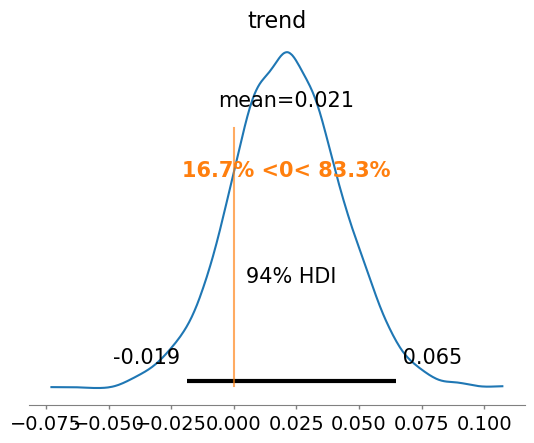

In [337]:
Ithaca.plot_trend_posterior("RX1day")

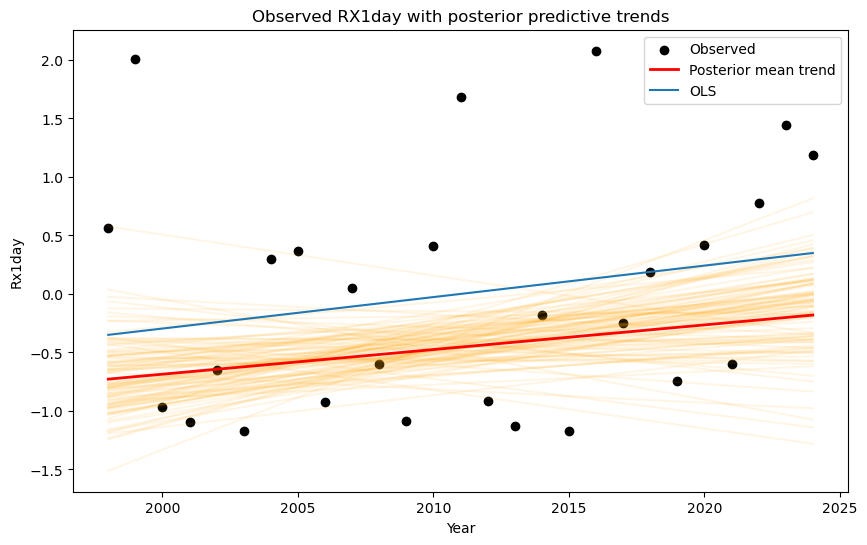

In [341]:
Ithaca.plot_posterior_predictive("RX1day")

### Same thing for R10
The number of days is Poisson distributed

In [342]:
Ithaca.fit_model("R10")
Ithaca.sample_model("R10")

We see a more robustly positive trend in R10

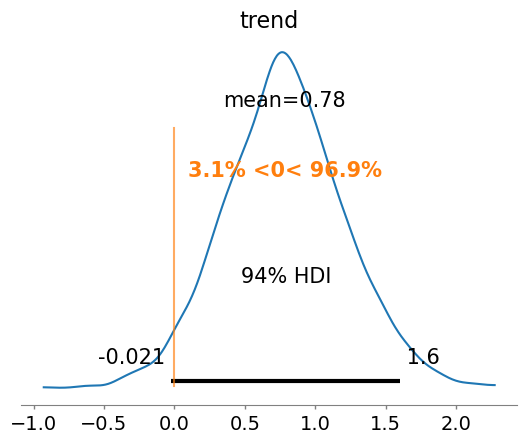

In [345]:
Ithaca.plot_trend_posterior("R10")

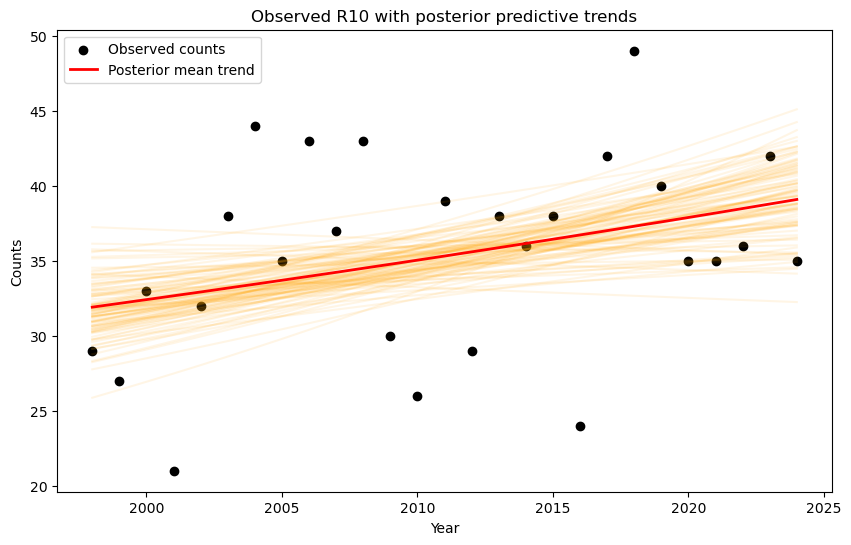

In [346]:
Ithaca.plot_posterior_predictive("R10")

# MLE for whole map 
No full posteriors for the whole map- takes too long.

In [338]:
da=NA.R10/np.timedelta64(1, 'D')

In [339]:

import statsmodels.api as sm


# -------------------------------
# Example data
ntime, nlat, nlon = da.shape 
np.random.seed(42)

# Function to fit Poisson GLM for one time series
def fit_poisson_glm(y_cell):
    # Only fit if there is some nonzero data
    if np.all(y_cell==0):
        return np.nan
    X = sm.add_constant(np.arange(len(y_cell)))  # design matrix: [1, t]
    model = sm.GLM(y_cell, X, family=sm.families.Poisson())
    res = model.fit()
    return res.params[1]  # return beta (slope)

# Apply over lat/lon using xarray's apply_ufunc
beta_map = xr.apply_ufunc(
    fit_poisson_glm,
    da,
    input_core_dims=[['time']],
    vectorize=True
)

print("Beta map (trend per year):")
#print(beta_map)


Beta map (trend per year):


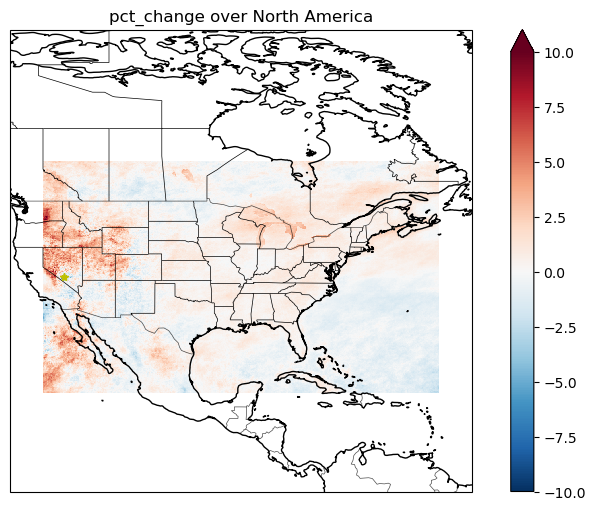

In [340]:
pct_change=100*(np.exp(beta_map)-1.)
import cartopy.feature as cfeature

# Assuming pct_change is your xarray DataArray with coords ["lat", "lon"]
# pct_change.lat, pct_change.lon

# Create the figure and specify a map projection
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent for North America (lon_min, lon_max, lat_min, lat_max)
ax.set_extent([-125, -55, 5, 75], crs=ccrs.PlateCarree())

# Plot the DataArray using xarray's built-in plot
pcm = pct_change.T.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),   # data is in lon/lat coords
    cmap="RdBu_r",
    add_colorbar=True,
    add_labels=False,
    vmin=-10,vmax=10
)

# Add coastlines and optional features
ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
#ax.add_feature(cfeature.LAND, facecolor='lightgray')


states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none'
)
ax.add_feature(states, edgecolor='black', linewidth=0.5)

# Get the flat index of the maximum value
flat_index = pct_change.argmin().item()

# Convert flat index to (i, j)
i, j = np.unravel_index(flat_index, pct_change.shape)
    
plt.plot(NA.lon[i],NA.lat[j],"y*")
plt.title("pct_change over North America")
plt.show()
